In [1]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/.julia/dev/DiffusionEvolution`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [6]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [5]:
d = 10
nsamples = 1000
T = 20

20

In [66]:
λ_diag = 0.1
λ_skew = 0.01
θ0 = fill(0.0, d)
θ1 = fill(5.0, d)
γ = 0.6
J, θ, min_eigv, max_eigv = random_pars(λ_diag, λ_skew, θ0, θ1, d=d);

In [67]:
min_eigv, max_eigv

(7.208075323860887, 14.305306299987032)

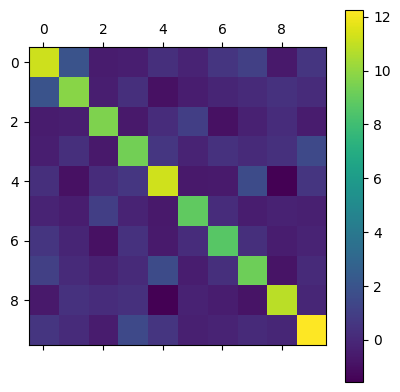

PyObject <matplotlib.colorbar.Colorbar object at 0x7c791bc72350>

In [68]:
matshow(inv(J))
colorbar()

In [69]:
θ |> norm

10.163528105185383

In [70]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

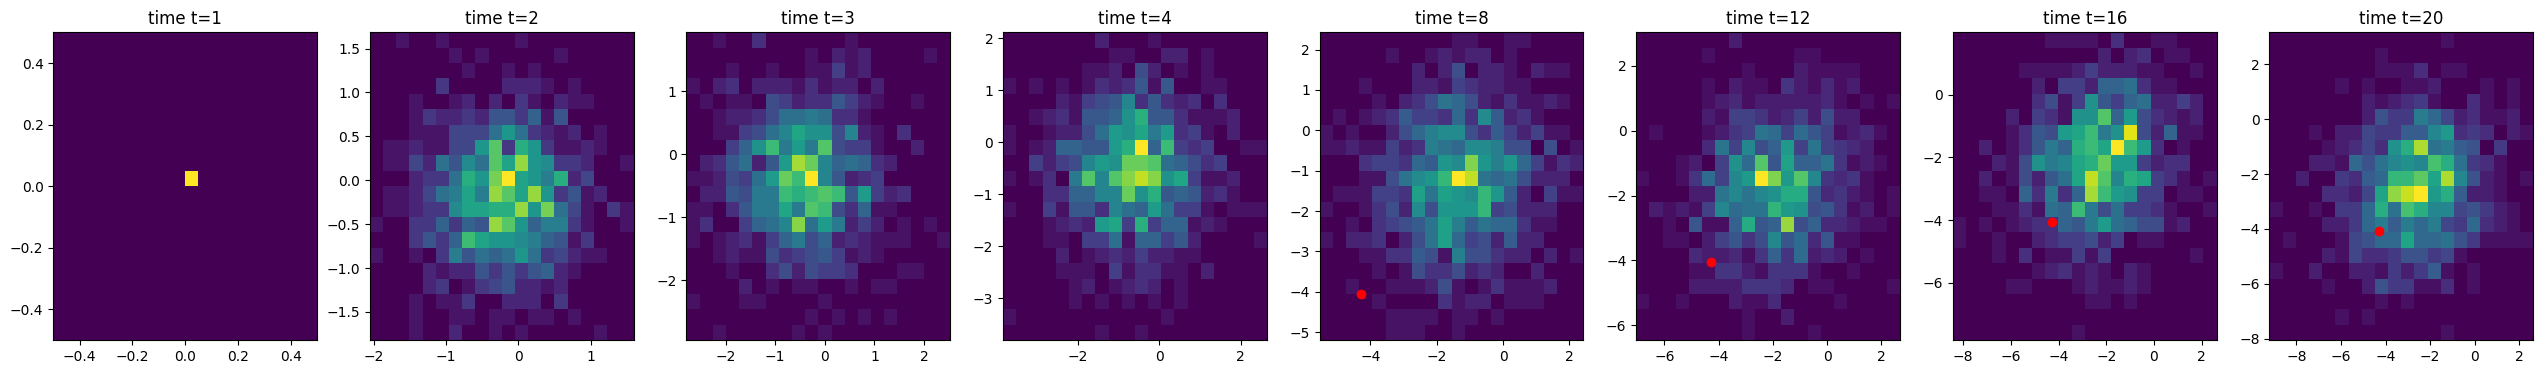

In [71]:
tpoints = [1,2,3,4,8,12,16,20]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

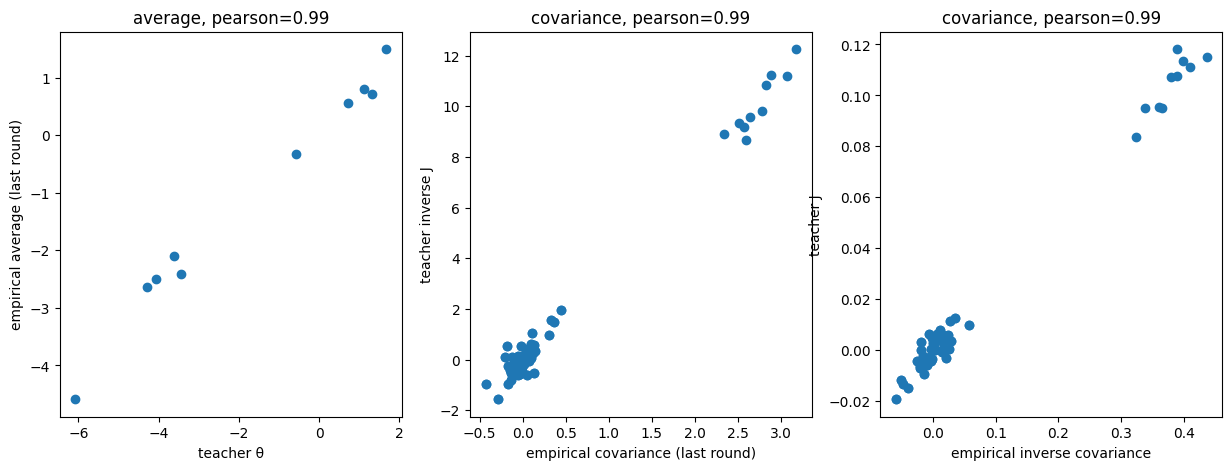

PyObject Text(0.5, 1.0, 'covariance, pearson=0.99')

In [72]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [73]:
counts = ones(nsamples, T) ./ nsamples
deltas = fill(1,T)
data = collect_data(x, counts, deltas);

In [81]:
l_values, x_opt, status = learn_nlopt(data, initialize=T, λ=0.0, prior=0.0, ftol_rel=1e-7)

(6.453447958065368, [0.4026065812857389, -0.08535979506635381, 0.43371118237894496, 0.008185795764126475, 0.026340885270836372, 0.45778579383423923, -0.013324838377934786, -0.03771079875662634, 0.02135835196010832, 0.43458789219820926  …  -2.338482237832553, -2.2145513036936206, 0.4654160506472453, -2.088379092632798, 0.6022975348479863, -4.000780116760952, 1.3153668771408242, 0.725786827252385, -0.24647835567948154, -1.839747666079416], :FTOL_REACHED)

In [82]:
J_inferred = de.compute_J(x_opt, data.d);

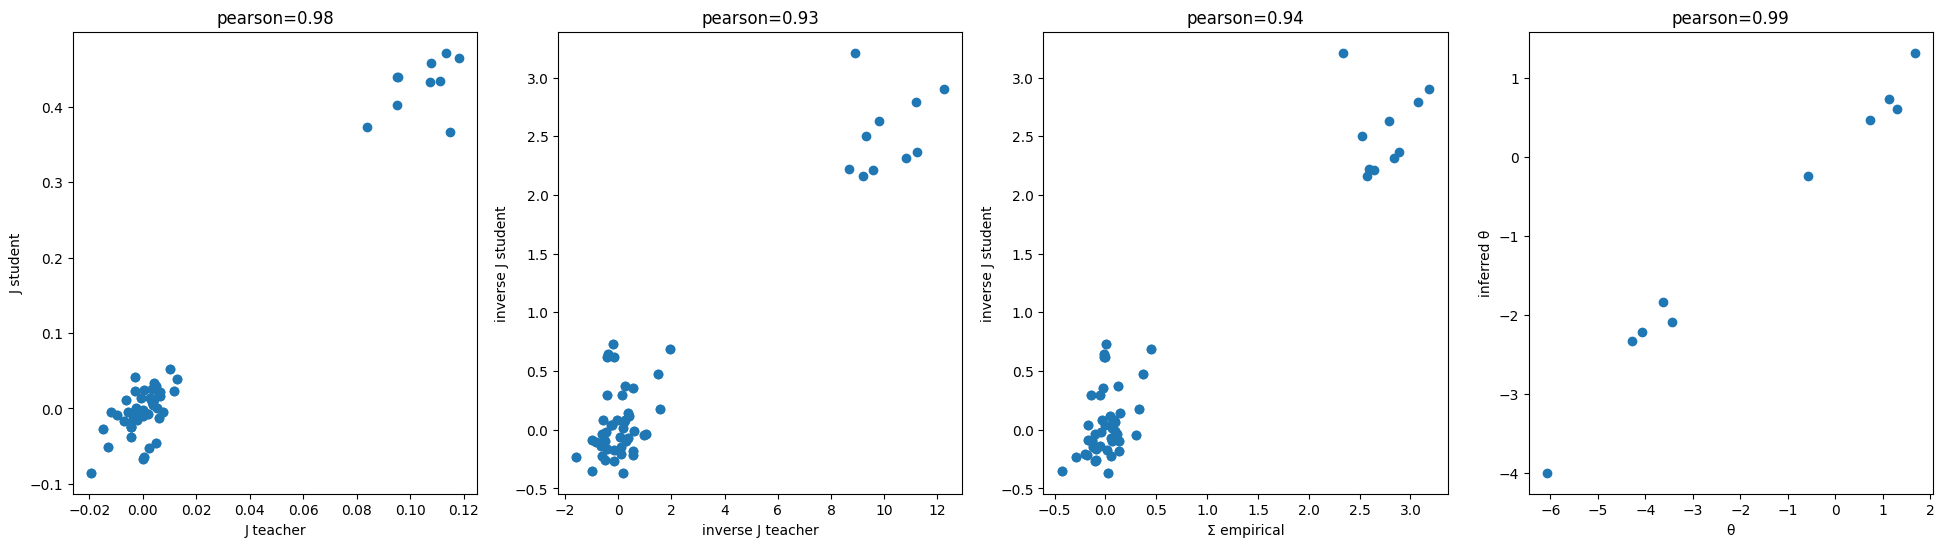

PyObject Text(0.5, 1.0, 'pearson=0.99')

In [83]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
rho_theta = cor(vec(θ), x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")

In [84]:
γ = vcat([0.001, 0.005], collect(0.1:0.1:1.5))

17-element Vector{Float64}:
 0.001
 0.005
 0.1
 0.2
 0.3
 0.4
 0.5
 0.6
 0.7
 0.8
 0.9
 1.0
 1.1
 1.2
 1.3
 1.4
 1.5

In [86]:
lγ = map(x->de.log_likelihood(x_opt, data, x, 0.0, 0.00), γ)

17-element Vector{Float64}:
 1761.9382392948905
  320.52031391053623
    2.7952168198215737
    0.05130188023508762
    0.649736564376604
    1.6521978670080002
    2.6538874753597628
    3.5764466177953445
    4.409810213898623
    5.160498243058829
    5.838467324754338
    6.453447958065368
    7.013995097073234
    7.527367920738736
    7.999654809775007
    8.435952722883714
    8.840539414862558

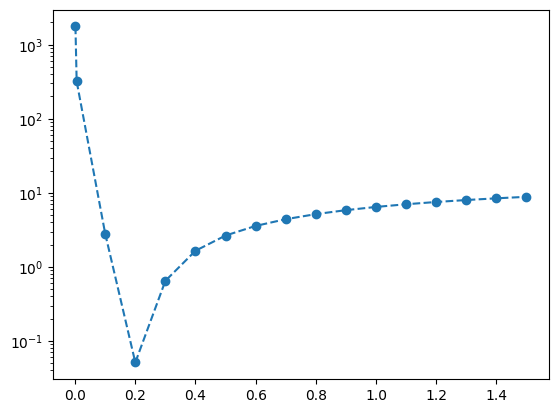

In [88]:
plot(γ, lγ, linestyle="dashed", marker="o")
yscale(:log)